In [9]:
from utils import *
results = load_save_file( save_dir="results", filename="rank_sweep_ngym_DMS_1000 iter, 10 sample_size.json")
metrics = load_metrics(results)
print(metrics)

{'rank_128': {'weight_dist': [0.05752259120345116, 0.06163782626390457, 0.07891057431697845, 0.06712096184492111, 0.048657603561878204, 0.053936030715703964, 0.043128885328769684, 0.022834716364741325, 0.06256010383367538, 0.03356136754155159, 0.07192055881023407, 0.05376617610454559, 0.021349158138036728, 0.05505892634391785, 0.14334918558597565, 0.036960870027542114, 0.045042481273412704], 'rep_sim': [0.7795184254646301, 0.9429997801780701, 0.9475193023681641, 0.9736951589584351, 0.9257083535194397, 0.9139333963394165, 0.9241141080856323, 0.9213659167289734, 0.909153401851654, 0.9555909633636475, 0.9594382047653198, 0.966244101524353, 0.9282558560371399, 0.9705065488815308, 0.8931261897087097, 0.9203693270683289, 0.943719208240509], 'sign_sim': [0.5742248892784119, 0.5731262564659119, 0.50726318359375, 0.5021697878837585, 0.5960602164268494, 0.5643035769462585, 0.574230968952179, 0.718853771686554, 0.5085541009902954, 0.6095337271690369, 0.5351501703262329, 0.5746734738349915, 0.6979

In [11]:
print(metrics["rank_1"])

{'weight_dist': [0.0012837068643420935, 0.0010913987644016743, 0.0005442498368211091, 0.0021044716704636812, 0.0007667834870517254, 0.0057619293220341206], 'rep_sim': [0.8890120983123779, 0.17040689289569855, 0.9999006986618042, 0.8922058343887329, 0.9968633055686951, 0.8670530915260315], 'sign_sim': [0.7557037472724915, 0.9303741455078125, 0.8667846918106079, 0.7299713492393494, 0.8222748041152954, 0.7360290884971619], 'kernel_alignment': [0.5278526544570923, 0.467683881521225, 0.0062061212956905365, 0.5341254472732544, 0.41689008474349976, 0.022369325160980225], 'loss': [0.5756402015686035, 0.5277853012084961, 0.5229316353797913, 0.7482380867004395, 0.24288398027420044, 0.5864616632461548]}


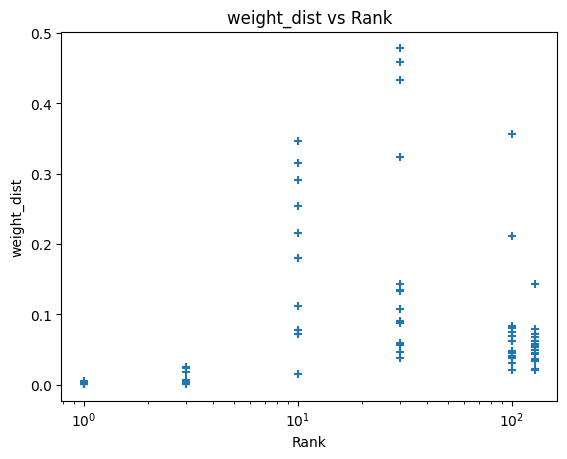

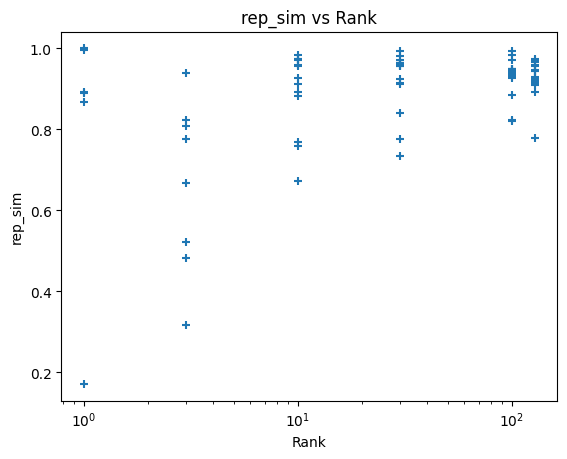

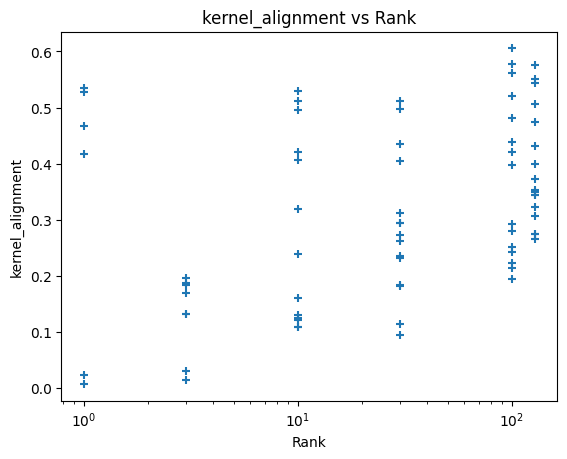

In [12]:
import matplotlib.pyplot as plt

def plot_metric_by_rank(results, metric):
    xs = []
    ys = []

    for rank_key, metrics in results.items():
        # extract numeric rank from "rank_10" → 10
        rank = int(rank_key.split("_")[1])

        if metric not in metrics:
            continue

        values = metrics[metric]

        xs.extend([rank] * len(values))  # repeat rank for each value
        ys.extend(values)

    plt.figure()
    plt.scatter(xs, ys, marker="+")
    plt.xlabel("Rank")
    plt.xscale("log")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Rank")
    plt.show()

plot_metric_by_rank(results, "weight_dist")
plot_metric_by_rank(results, "rep_sim")
plot_metric_by_rank(results, "kernel_alignment")
